# HR Analytics — Data Cleaning & Exploratory Analysis

## 1. Project Objective

This project focuses on cleaning and analyzing an HR dataset containing approximately 10,000 employee records with intentional data-quality issues.

The objective is to prepare the dataset for reliable HR analysis and identify insights related to workforce demographics, salary distribution, departmental composition, and employee joining trends.

## 2. Import Libraries

In [2]:
import numpy as np
import pandas as pd 

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns 

## 3. Load Dataset

In [4]:
url = "https://raw.githubusercontent.com/swapnilsaurav/projects/refs/heads/main/Data%20Cleaning%20for%20HR%20Analytics%20v1.csv"

df = pd.read_csv(url)

## 4. Initial Data Inspection

In [5]:
df.head()

,ID,Name,Email,Age,JoinDate,Salary,Department,Remarks
0,1,Andrew Anthony,keith70@hotmail.com,21.0,2024-07-26,47603.16,Sales,Average
1,2,Ashley Hudson,kelly10@reed.com,26.0,2025-01-27,76963.20,HR,Poor
2,3,Kristin Ross,johnsonisaiah@hotmail.com,20.0,2021-03-19,102398.18,Finance,NaN
3,4,Kelli Cook,ydavis@yahoo.com,33.0,2022-03-15,81912.56,NaN,Good
4,5,Heather King,xtaylor@hotmail.com,59.0,2024-01-12,72918.09,NaN,NaN


In [6]:
df.tail()

,ID,Name,Email,Age,JoinDate,Salary,Department,Remarks
10195,4233,Nathaniel Duarte,kaylabullock@gmail.com,NaN,2022-08-12,89404.51,Finance,NaN
10196,6937,Anthony Brewer,gward@hotmail.com,21.0,2021-09-20,84979.39,HR,Poor
10197,8416,NaN,nichole78@dorsey.org,58.0,2023-05-26,NaN,Finance,NaN
10198,7760,Daniel Villanueva,angela55@gmail.com,44.0,2021-07-02,42928.03,Engineering,Good
10199,9542,Paul Davies,gregorylindsey@avila-sullivan.com,21.0,2025-05-11,30886.09,Engineering,NaN


In [7]:
df.shape

(10200, 8)

In [8]:
df.columns

Index(['ID', 'Name', 'Email', 'Age', 'JoinDate', 'Salary', 'Department',
       'Remarks'],
      dtype='object')

In [9]:
df.dtypes

ID              int64
Name           object
Email          object
Age           float64
JoinDate       object
Salary        float64
Department     object
Remarks        object
dtype: object

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          10200 non-null  int64  
 1   Name        10106 non-null  object 
 2   Email       10200 non-null  object 
 3   Age         10076 non-null  float64
 4   JoinDate    10200 non-null  object 
 5   Salary      9679 non-null   float64
 6   Department  8166 non-null   object 
 7   Remarks     6144 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 637.6+ KB


In [11]:
df.isnull().sum()

ID               0
Name            94
Email            0
Age            124
JoinDate         0
Salary         521
Department    2034
Remarks       4056
dtype: int64

## 5. Data Quality Assessment
The raw dataset was profiled to identify missing values, placeholder values, invalid numerical values, inconsistent categorical fields, duplicate records, and potentially corrupt dates.

In [12]:
df.duplicated().sum()

197

In [147]:
df[df.duplicated()]

,ID,Name,Email,Age,JoinDate,Salary,Department,Remarks
10000,9954,Emily Smith,wagnerapril@hotmail.com,53.0,2025-05-28,37225.690000,Finance,No Remarks
10001,3851,Dominic Kelley,sharon40@shepherd-mckenzie.info,61.0,2023-01-09,109424.640000,Finance,No Remarks
10002,4963,Melissa Norris,christyhatfield@yahoo.com,38.0,2021-10-18,30573.090000,HR,No Remarks
10003,3887,Erica Simmons,taylor18@mcmillan-mahoney.com,31.0,2023-02-17,44311.340000,Finance,Good
10004,5438,Heather Guzman,jessemartin@yahoo.com,36.0,2021-03-23,97905.770000,Not Specified,No Remarks
...,...,...,...,...,...,...,...,...
10195,4233,Nathaniel Duarte,kaylabullock@gmail.com,44.0,2022-08-12,89404.510000,Finance,No Remarks
10196,6937,Anthony Brewer,gward@hotmail.com,21.0,2021-09-20,84979.390000,HR,Poor
10197,8416,NaN,nichole78@dorsey.org,58.0,2023-05-26,75626.727204,Finance,No Remarks
10198,7760,Daniel Villanueva,angela55@gmail.com,44.0,2021-07-02,42928.030000,Engineering,Good


In [148]:
df = df.drop_duplicates()

In [149]:
df[df.duplicated()]

,ID,Name,Email,Age,JoinDate,Salary,Department,Remarks


In [150]:
df["Name"].value_counts(dropna=False)

Name
NaN                92
Jennifer Brown      6
Stephanie Smith     6
James Thomas        6
Robert Davis        6
                   ..
Henry Richard       1
Kelli Waters        1
Kathy Foley         1
Linda Cox           1
Danielle Myers      1
Name: count, Length: 9280, dtype: int64

In [151]:
df["Email"].value_counts(dropna=False)

Email
NaN                           238
pdavis@yahoo.com                3
urogers@hotmail.com             3
dramirez@yahoo.com              2
dwilliams@hotmail.com           2
                             ... 
chenjames@yahoo.com             1
crystal99@yahoo.com             1
thomasmullins@hotmail.com       1
rodriguezcolleen@yahoo.com      1
breilly@gmail.com               1
Name: count, Length: 9719, dtype: int64

In [116]:
df["Department"].value_counts(dropna=False)

Department
HR               2034
Finance          2005
Not Specified    2005
Sales            1988
Engineering      1971
Name: count, dtype: int64

In [117]:
df["Remarks"].value_counts(dropna=False)

Remarks
No Remarks    3972
Average       2059
Poor          1999
Good          1973
Name: count, dtype: int64

In [118]:
df["Age"].unique()

array([21., 26., 20., 33., 59., 36., 48., 27., 28., 30., 23., 50., 51.,
       60., 49., 44., 57., 68., 63., 34., 67., 40., 24., 64., 38., 69.,
       29., 22., 25., 43., 54., 45., 58., 52., 55., 18., 31., 42., 66.,
       56., 32., 41., 39., 70., 19., 46., 35., 37., 47., 62., 53., 61.,
       65.])

In [119]:
df["Age"].value_counts(dropna=False).sort_index()

Age
18.0    192
19.0    156
20.0    184
21.0    188
22.0    198
23.0    189
24.0    197
25.0    176
26.0    208
27.0    183
28.0    191
29.0    190
30.0    194
31.0    171
32.0    178
33.0    204
34.0    194
35.0    192
36.0    201
37.0    198
38.0    195
39.0    171
40.0    186
41.0    164
42.0    199
43.0    196
44.0    329
45.0    188
46.0    174
47.0    160
48.0    193
49.0    180
50.0    156
51.0    178
52.0    179
53.0    174
54.0    206
55.0    194
56.0    210
57.0    170
58.0    169
59.0    183
60.0    185
61.0    200
62.0    178
63.0    202
64.0    201
65.0    174
66.0    169
67.0    199
68.0    178
69.0    193
70.0    186
Name: count, dtype: int64

In [120]:
df["Salary"].isnull().sum()

0

In [121]:
df["Salary"].min(), df["Salary"].max()

(30001.05, 119981.54)

In [122]:
df["Salary"].dtypes

dtype('float64')

## 6. Data Cleaning

The dataset was cleaned systematically by addressing invalid values, missing values, inconsistent fields, and corrupt dates while preserving records where reliable replacement values could not be inferred.

### 6.1 Email Cleaning

In [124]:
df["Email"] = df["Email"].replace(
    ["unknown", "not_an_email"],
    np.nan
)

### 6.2 Age Cleaning

In [125]:
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

df["Age"] = df["Age"].apply(
    lambda x: x if 18 <= x <= 70 else np.nan
)

age_median = df["Age"].median()

df["Age"] = df["Age"].fillna(age_median)

### 6.3 Salary Cleaning

In [126]:
df["Salary"] = pd.to_numeric(
    df["Salary"],
    errors="coerce"
)

df["Salary"] = df["Salary"].apply(
    lambda x: x if x >= 0 else np.nan
)

df["Salary"].isnull().sum()

572

In [127]:
df["Salary"].describe()

count      9628.000000
mean      75626.727204
std       25969.245223
min       30001.050000
25%       53305.915000
50%       76296.090000
75%       98233.427500
max      119981.540000
Name: Salary, dtype: float64

In [128]:
df["Salary"].skew()

-0.05649606276407715

In [129]:
salary_mean = df["Salary"].mean()

salary_mean

75626.72720398837

In [130]:
df["Salary"] = df["Salary"].fillna(salary_mean)

In [131]:
df["Salary"].isnull().sum()

0

In [132]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [133]:
Q1,Q3,IQR,lower_bound,upper_bound

(54651.5175, 96871.8775, 42220.36, -8679.0225, 160202.4175)

In [134]:
outliers = df[
    (df["Salary"] < lower_bound) |
    (df["Salary"] > upper_bound)
]

outliers.shape

(0, 8)

### 6.4 JoinDate Cleaning

In [135]:
df["JoinDate"] = pd.to_datetime(
    df["JoinDate"],
    errors="coerce"
)

In [136]:
df["JoinDate"].dtype

dtype('<M8[ns]')

### 6.5 Department Cleaning

In [137]:
df["Department"] = df["Department"].fillna(
    "Not Specified"
)

In [138]:
df["Department"].isnull().sum()

0

### 6.6 Remarks Cleaning

In [139]:
df["Remarks"] = df["Remarks"].fillna(
    "No Remarks"
)

In [140]:
df["Remarks"].isnull().sum()

0

## 7. Data Validation

The cleaned dataset was validated by checking remaining missing values, duplicate records, numerical ranges, salary statistics, and final data types.

In [141]:
df.isnull().sum()

ID              0
Name           94
Email         241
Age             0
JoinDate       11
Salary          0
Department      0
Remarks         0
dtype: int64

In [142]:
df["Salary"].isnull().sum()

0

In [143]:
df["Salary"].describe()

count     10200.000000
mean      75626.727204
std       25230.509309
min       30001.050000
25%       54651.517500
50%       75626.727204
75%       96871.877500
max      119981.540000
Name: Salary, dtype: float64

In [144]:
df.dtypes

ID                     int64
Name                  object
Email                 object
Age                  float64
JoinDate      datetime64[ns]
Salary               float64
Department            object
Remarks               object
dtype: object

In [107]:
print("Dataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum())

print("\nAge range:", df["Age"].min(), "-", df["Age"].max())
print("Negative salaries:", (df["Salary"] < 0).sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: (10003, 9)
Duplicate rows: 0

Missing values:
ID              0
Name           92
Email         238
Age             0
JoinDate       11
Salary          0
Department      0
Remarks         0
JoinYear       11
dtype: int64

Age range: 18.0 - 70.0
Negative salaries: 0

Data types:
ID                     int64
Name                  object
Email                 object
Age                  float64
JoinDate      datetime64[ns]
Salary               float64
Department            object
Remarks               object
JoinYear             float64
dtype: object


In [145]:
df.to_csv("HR_Analytics_Cleaned.csv", index=False)

## 8. Exploratory Data Analysis

### 8.1 Employee Age Distribution

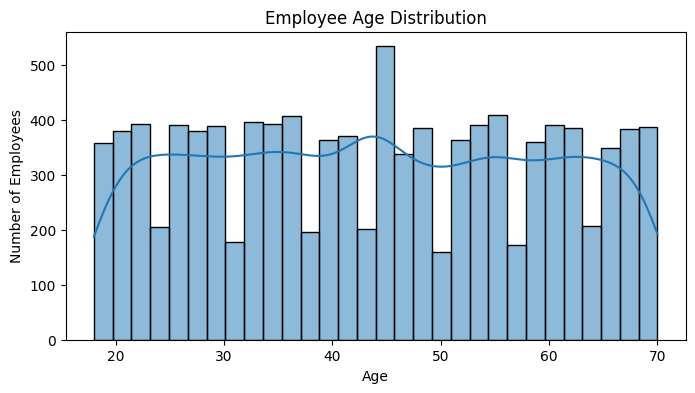

In [146]:
plt.figure(figsize=(8, 4))

sns.histplot(
    df["Age"],
    bins=30,
    kde=True
)

plt.title("Employee Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.show()

### 8.2 Salary Distribution

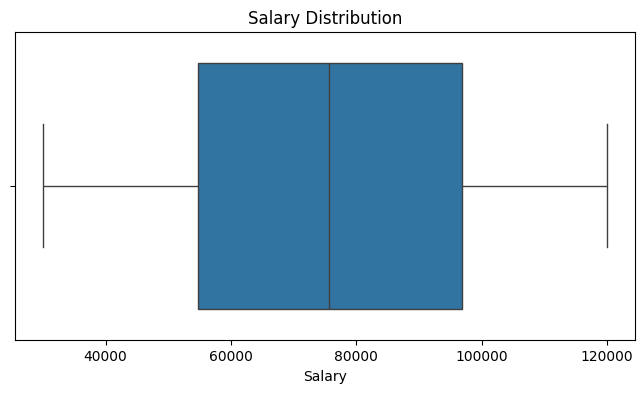

In [99]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["Salary"])

plt.title("Salary Distribution")
plt.xlabel("Salary")

plt.show()

In [100]:
df["Salary"].describe()

count     10003.000000
mean      75642.683151
std       25211.969552
min       30001.050000
25%       54731.695000
50%       75626.727204
75%       96868.490000
max      119981.540000
Name: Salary, dtype: float64

### 8.3 Department Distribution

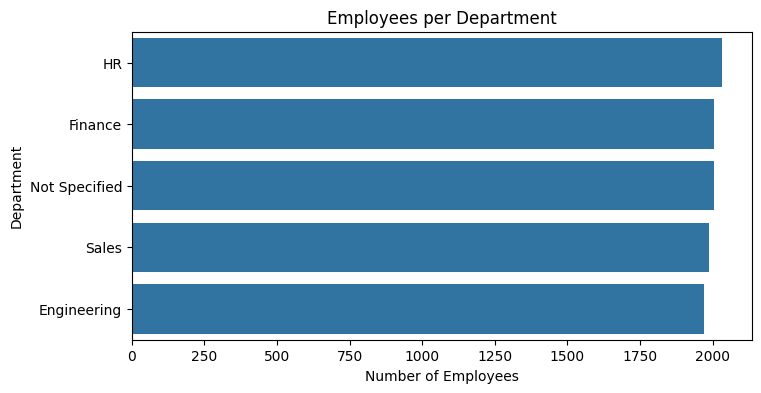

In [101]:
plt.figure(figsize=(8, 4))

sns.countplot(
    y="Department",
    data=df,
    order=df["Department"].value_counts().index
)

plt.title("Employees per Department")
plt.xlabel("Number of Employees")
plt.ylabel("Department")

plt.show()

In [102]:
df["Department"].value_counts()

Department
HR               2034
Finance          2005
Not Specified    2005
Sales            1988
Engineering      1971
Name: count, dtype: int64

### 8.4 Employee Joining Trend

In [103]:
df["JoinYear"] = df["JoinDate"].dt.year

In [104]:
df["JoinYear"].value_counts().sort_index()

JoinYear
2020.0    1051
2021.0    1948
2022.0    1981
2023.0    1998
2024.0    2072
2025.0     942
Name: count, dtype: int64

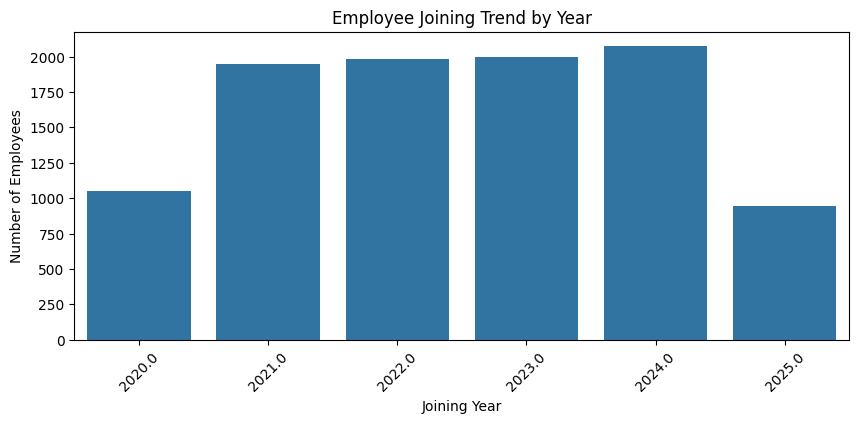

In [105]:
plt.figure(figsize=(10, 4))

sns.countplot(
    x="JoinYear",
    data=df.sort_values("JoinYear")
)

plt.title("Employee Joining Trend by Year")
plt.xlabel("Joining Year")
plt.ylabel("Number of Employees")

plt.xticks(rotation=45)

plt.show()

In [106]:
df["JoinDate"].min(), df["JoinDate"].max()

(Timestamp('2020-06-21 00:00:00'), Timestamp('2025-06-21 00:00:00'))

## Business Insights

1. The workforce is relatively evenly distributed across the specified departments, with HR having the highest employee count at 2,034 and Engineering the lowest at 1,971.

2. Approximately 20% of employee records have no department specified, highlighting a data-quality gap that could affect department-level workforce planning and reporting.

3. Salary data showed a relatively symmetric distribution, with skewness close to zero. After handling missing and invalid salary values, no observations fell outside the IQR-based outlier boundaries.

4. Employee joining counts increased steadily from 2021 through 2024, reaching the highest full-year count in 2024 with 2,072 employees.

5. The 2025 joining count should not be interpreted as a decline in hiring because the dataset only contains records through June 21, 2025.



## Conclusion

The HR dataset was cleaned and validated using Python and Pandas by addressing missing values, invalid records, inconsistent fields, and date-format issues. Exploratory analysis using Matplotlib and Seaborn was then performed to understand workforce demographics, salary distribution, departmental composition, and employee joining trends.

The analysis also highlighted a significant gap in department information, which could affect workforce reporting and planning. The cleaned dataset provides a more reliable foundation for HR analysis and future reporting.